In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

In [4]:
path = '/home/haitong/PycharmProjects/lvrep-rl-cloned/log'
noise_levels = [0.0, 1.0, 2.0, 3.0]
dfs = []
for env in sorted(os.listdir(path)):
    if os.path.isdir(os.path.join(path, env)) and env.startswith('Pendulum-v1_'):
        env_path = os.path.join(path, env)
        for algo in os.listdir(env_path):
           algo_path = os.path.join(env_path, algo)
           exp = os.listdir(algo_path)[0]
           df = pd.read_csv(os.path.join(algo_path, exp, 'log.csv'))
           sliced_df = df[df['step']==80000]
           sliced_df['noise'] = env.split('sigma_')[1][:3]
           if algo.startswith('sac'):
               sliced_df['algo'] = 'SAC'
           elif algo.startswith('rfsac_nystrom_False'):
               sliced_df['algo'] = 'SDEC (RF)'
           elif algo.startswith('rfsac_nystrom_True'):
               sliced_df['algo'] = 'SDEC (Nystrom)'
           dfs.append(sliced_df)
           
total_df = pd.concat(dfs, ignore_index=True)

nonlinear_control_df = {
    'avg_ret': [-1090, -1050, -844, -805, -1084, -1331,-1265, -1208, -896, -1604, -1302, -1457,],
    'std_ret': [236, 225, 320, 331, 124, 235, 321, 342, 128, 288, 352, 416],
    'step': [80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, ],
    'algo': ['DKUC', 'DKUC', 'DKUC', 'DKUC', 'iLQR', 'iLQR', 'iLQR', 'iLQR', 'Energy-based', 'Energy-based', 'Energy-based', 'Energy-based', ],
    'noise': ['0.0', '1.0', '2.0', '3.0', '0.0', '1.0', '2.0', '3.0', '0.0', '1.0', '2.0', '3.0', ],

}
nonlinear_control_df = pd.DataFrame.from_dict(nonlinear_control_df)
total_df = pd.concat([total_df, nonlinear_control_df], ignore_index=True)
print(total_df)

     step      avg_ret     std_ret noise            algo
0   80000  -247.741742  169.294823   0.0             SAC
1   80000  -245.578495  175.608666   0.0  SDEC (Nystrom)
2   80000  -245.578495  175.608666   0.0       SDEC (RF)
3   80000  -260.929993  178.938241   1.0             SAC
4   80000  -237.811141  174.281600   1.0  SDEC (Nystrom)
5   80000  -242.062357  172.536738   1.0       SDEC (RF)
6   80000  -729.488585  142.848931   2.0             SAC
7   80000  -251.352516  170.487410   2.0  SDEC (Nystrom)
8   80000  -251.620543  169.428192   2.0       SDEC (RF)
9   80000  -847.023253  112.000488   3.0             SAC
10  80000  -595.650466  172.263886   3.0  SDEC (Nystrom)
11  80000  -403.076716  177.195004   3.0       SDEC (RF)
12  80000 -1090.000000  236.000000   0.0            DKUC
13  80000 -1050.000000  225.000000   1.0            DKUC
14  80000  -844.000000  320.000000   2.0            DKUC
15  80000  -805.000000  331.000000   3.0            DKUC
16  80000 -1084.000000  124.000

/tmp/ipykernel_633334/142260731.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['noise'] = env.split('sigma_')[1][:3]
/tmp/ipykernel_633334/142260731.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['algo'] = 'SAC'
/tmp/ipykernel_633334/142260731.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

[Text(0, -1500.0, '−1500'), Text(0, -1000.0, '−1000'), Text(0, -500.0, '−500'), Text(0, 0.0, '0'), Text(0, 500.0, '500')]


/tmp/ipykernel_633334/3048502445.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), fontname="Times New Roman")
/tmp/ipykernel_633334/3048502445.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontname="Times New Roman")


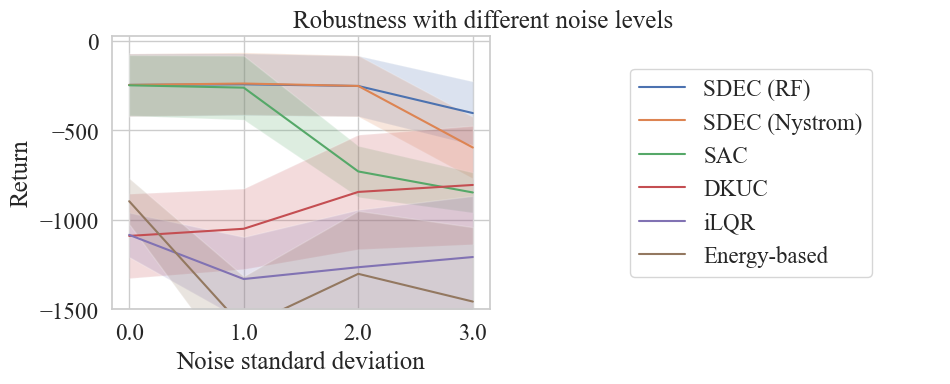

In [12]:
# sns.set_style('white')
sns.set(font_scale=1.5, style='whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plt.rcParams['font.family'] = 'Times New Roman'
hue_order = ['SDEC (RF)', 'SDEC (Nystrom)', 'SAC', 'DKUC', 'iLQR', 'Energy-based']
# ax = sns.barplot(x='noise', y='avg_ret', hue='algo', data=total_df, hue_order=hue_order)
# 

sns.lineplot(x='noise', y='avg_ret', hue='algo', data=total_df, hue_order=hue_order, ax=ax1)
# total_df = total_df.map(lambda x: 'Algorithm' if x == 'algo' else x)

for i, alg in enumerate(hue_order):
    if i < 12:
        # alg = hue_order[alg_index]
        # print(bar.get_x(), bar.get_height())
        # ax.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(), total_df[total_df['algo'] == alg]['std_ret'].iloc[i % 4],
        #             color='black')
        avg = total_df[total_df['algo'] == alg]['avg_ret']
        std = total_df[total_df['algo'] == alg]['std_ret']
        ax1.fill_between(np.arange(4) , avg-std, avg + std, alpha=0.2)
ax1.set_ylabel('Return', fontname="Times New Roman")
ax1.set_ylim([-1500, ax1.get_ylim()[1]])
ax1.set_xlabel('Noise standard deviation', fontname="Times New Roman")
ax1.set_xticklabels(ax1.get_xticklabels(), fontname="Times New Roman")
print(ax1.get_yticklabels())
ax1.set_yticklabels(ax1.get_yticklabels(), fontname="Times New Roman")
plt.tight_layout()
h, l = ax1.get_legend_handles_labels()
ax2.legend(h, l, loc='center')
ax2.axis('off')
ax1.get_legend().remove()
plt.suptitle('Robustness with different noise levels', fontsize=18)

fig.savefig('/home/haitong/PycharmProjects/lvrep-rl-cloned/utils/robustness_eval.pdf')

ValueError: The value for `errorbar` must be one of ['ci', 'pi', 'se', 'sd'], but None was passed.

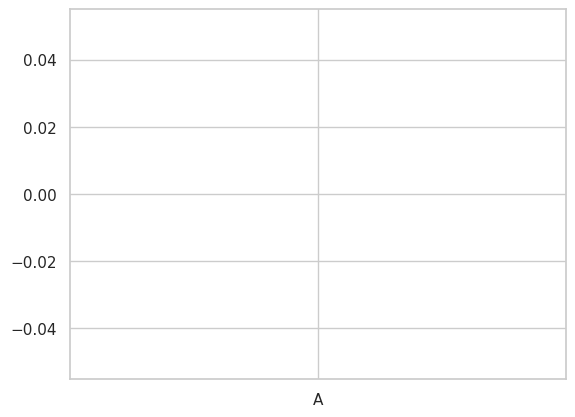

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample data
data = pd.DataFrame({
    "category": ["A", "B", "C"],
    "value": [10, 15, 7]
})

# Manually set error values
error_values = [2, 1.5, 3]  # Errors for A, B, and C

# Using Seaborn's barplot with custom error values
sns.barplot(
    data=data,
    x="category",
    y="value",
    errorbar=(None, error_values),  # Custom error bars
    capsize=0.2                     # Add caps to the error bars
)

plt.show()


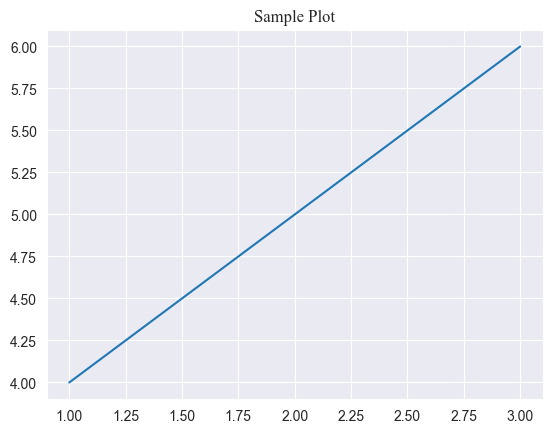

In [1]:
import matplotlib.pyplot as plt
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("Sample Plot", fontname="Times New Roman")
plt.show()
